In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth
    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False
def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start
    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.

        return state == self.goal
        # raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.

        legal_actions =[]
        for action in MOVES:
             dr,dc = MOVES[action]
             next_state = (state[0]+dr, state[1]+dc)
             if self.in_bounds(next_state) and self.is_free(next_state):
                  legal_actions.append(action)
        return legal_actions 
        
        # raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)

        dr, dc = MOVES[action]
        return (state[0] + dr, state[1] +dc)
       # raise NotImplementedError("Complete GridProblem.result")
      

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.

        cost =1
        return cost
        # raise NotImplementedError("Complete GridProblem.action_cost")

In [6]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [7]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [8]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

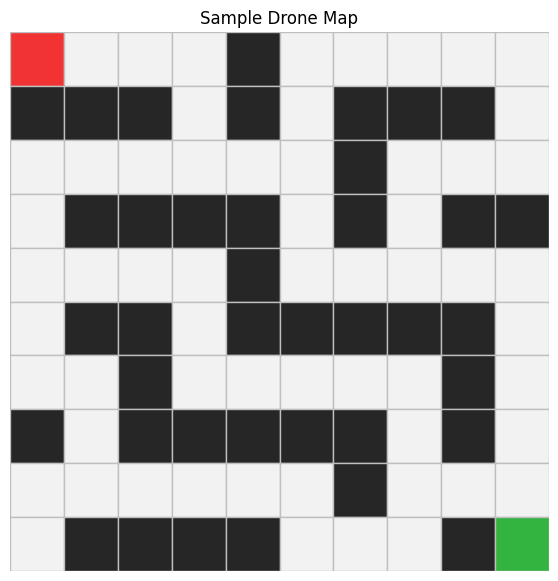

In [9]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [10]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s,action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state = s_prime, parent = node, action = action, path_cost = cost)

        #raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [11]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
        node = Node(state = problem.initial_state())
        if problem.is_goal(node.state):
        
            return SearchResult( 
                algorithm = algorithm,
                status = "success",
                solution = node,
                nodes_expanded = 0,
                max_frontier_size =1
                )
        frontier = deque([node])
        reached = set()
        reached.add (node.state)
        
        nodes_expanded = 0
        max_frontier_size =1


        while frontier:
            node = frontier.popleft()
            nodes_expanded +=1
            for child in self.expand(problem, node):
                s = child.state
                
                if problem.is_goal(s):
                    return SearchResult(algorithm = algorithm,
                    status = "success",
                    solution = child,
                    nodes_expanded = nodes_expanded,
                    max_frontier_size = max_frontier_size
                    )
                   
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
            max_frontier_size = max(max_frontier_size, len(frontier))
        return SearchResult(
                    algorithm = algorithm,
                    status = "failure",
                    solution = None,
                    nodes_expanded = nodes_expanded,
                    max_frontier_size = max_frontier_size
                    )

        #raise NotImplementedError("Complete BreadthFirstSearch.search")

In [12]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        
        node = Node(state = problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult( 
                algorithm = algorithm,
                status = "success",
                solution = node,
                nodes_expanded = 0,
                max_frontier_size =1
                )
        frontier = [node]
        reached = set()
        
        nodes_expanded =0
        max_frontier_size =1


        while frontier:
            node = frontier.pop()
            nodes_expanded +=1

            for child in self.expand(problem,node):
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(algorithm = algorithm,
                    status ="success",
                    solution = child,
                    nodes_expanded = nodes_expanded,
                    max_frontier_size = max_frontier_size)
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(algorithm = algorithm,
                    status = "failure",
                    solution = None,
                    nodes_expanded = nodes_expanded,
                    max_frontier_size = max_frontier_size
                    )

        #raise NotImplementedError("Complete DepthFirstSearch.search")

In [13]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )
    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")

        if problem.is_goal(node.state):
            return (node, "success")
        elif node.depth >= limit:
            return (None, "cutoff")
        else:
            metrics["nodes_expanded"] +=1
            cutoff_occurred = False
            
            for child in self.expand(problem, node):
                if state_is_on_path(node, child.state): # checks for cycles 
                    continue
                metrics["max_stack_size"] = max(
                    metrics["max_stack_size"], 
                    current_stack_size +1)
                
                result, status = self._recursive_dls(problem, child, limit, metrics, current_stack_size +1)
                if status =="success":
                    return (result, "success")
                
                if status =="cutoff":
                    cutoff_occurred = True

            if cutoff_occurred:
                return (None, "cutoff")
            else:
                return (None, "failure")
                

        #raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")
    

In [14]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)

        iteration_log =[]
        total_nodes_expanded = 0
        max_stack_size =0
        for limit in range(max_depth +1):
            dls = DepthLimitedSearch()
            result = dls.search(problem,limit = limit)
            total_nodes_expanded += result.nodes_expanded
            max_stack_size = max(max_stack_size, result.max_frontier_size)
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
                "max_stack_size": result.max_frontier_size})
            
            if result.status == "success":
                return SearchResult(
                    algorithm = algorithm,
                    status = "success",
                    solution = result.solution,
                    nodes_expanded = total_nodes_expanded,
                    max_frontier_size = max_stack_size
                )
            elif result.status =="failure":
                return SearchResult(
                    algorithm = algorithm,
                    status = "failure",
                    solution = None,
                    nodes_expanded = total_nodes_expanded,
                    max_frontier_size = max_stack_size)
        return SearchResult(
            algorithm = algorithm,
            status = "cutoff",
            solution = None,
            nodes_expanded = total_nodes_expanded,
            max_frontier_size = max_stack_size
            )
        

        #raise NotImplementedError("Complete IterativeDeepeningSearch.search")

In [15]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,0
1,DFS,success,NaN,18.0,18.0,18,5,0
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,NaN,18.0,18.0,356,19,0


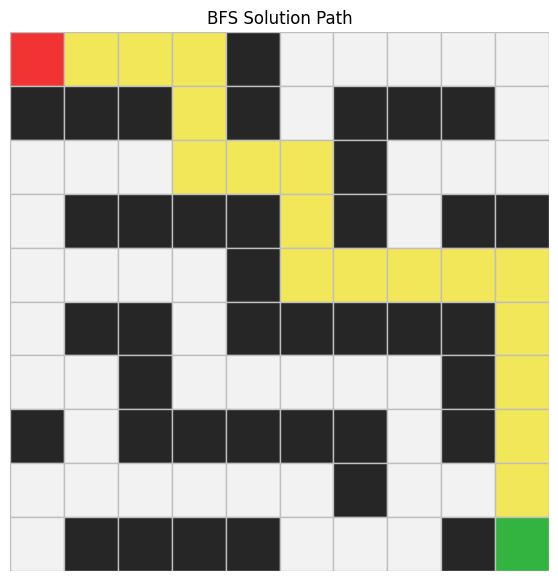

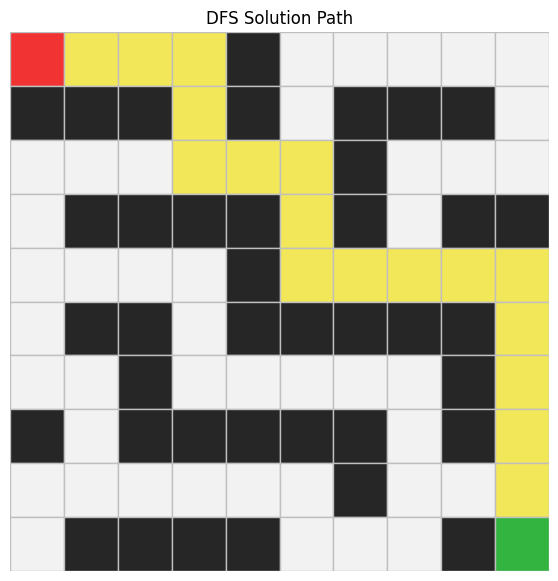

In [16]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [17]:
# TODO 10:
# Create your first custom map here.

# A map with many dead ends
custom_grid_1 =[
    [1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,1,1,0,1],
    [1,0,1,0,0,0,0,1,0,0,1,0,1],
    [1,0,1,0,1,1,1,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,0,1,0,0,1],
    [1,0,1,1,1,1,1,0,1,1,0,1,1],
    [1,0,0,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,0,1,1,1,1,1,0,1],
    [1,0,0,0,0,0,0,0,0,0,1,0,1],
    [1,0,1,1,1,1,1,1,1,0,1,0,1],
    [1,0,0,0,0,0,0,0,1,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1]
]

custom_start_1 = (1,1)
custom_goal_1 = (11,11)

custom_problem_1 = GridProblem(
    custom_grid_1,
    custom_start_1,
    custom_goal_1
)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

show_results(custom_results_1)



,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,20,20,63,5,0
1,DFS,success,NaN,26,26,26,5,0
2,DLS,success,20.0,20,20,27,21,0
3,IDS,success,NaN,20,20,519,21,0


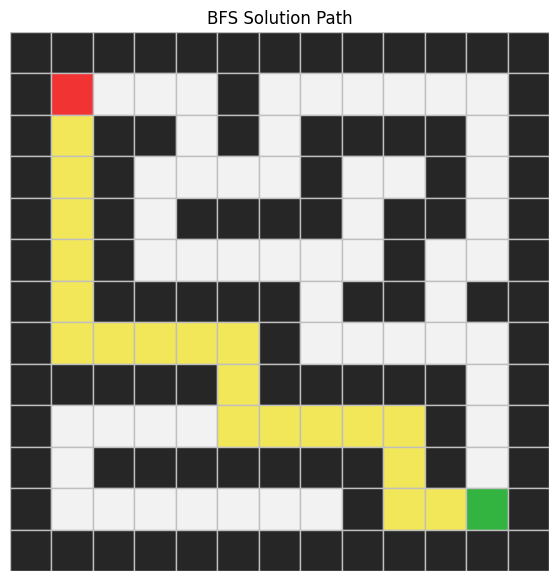

In [18]:
path = custom_results_1[0].path
bfs_result = results[0]
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=path,
    title="BFS Solution Path",
)

Interpretation:
This map was designed with many dead ends to test how different search algorithms handle misleading paths. BFS successfully found the shortest path with a solution depth and cost of 20. However, it expanded 63 nodes because it explores many alternative paths before reaching the goal. DFS also found a solution, but with a greater depth and cost of 26, indicating that it explored deeper branches and several dead ends before finding the goal. DLS successfully found the same optimal solution as BFS because the depth limit of 20 was exactly equal to the solution depth. IDS also found the optimal solution, but it expanded 519 nodes, significantly more than the other algorithms, because it repeatedly performs depth-limited searches from depth 0 up to the solution depth. Overall, the results show that BFS, DLS, and IDS were able to find the optimal solution, while DFS was less efficient due to its characteristics of following deeper paths.


In [19]:
# TODO 11:
# Create your second custom map here.

# A map where DFS is likely to enter dead ends before finding the goal.
custom_grid_2 = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,0,1,1,1,1,1,0,1,0,1],
    [1,0,1,0,0,0,1,0,1,0,1],
    [1,0,1,0,1,0,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1]
]

custom_start_2 = (1,1)
custom_goal_2 = (9,8)

custom_problem_2 = GridProblem(
    custom_grid_2,
    custom_start_2,
    custom_goal_2
)

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]

show_results(custom_results_2)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,23.0,23.0,31,3,0
1,DFS,success,NaN,23.0,23.0,29,4,0
2,DLS,cutoff,20.0,NaN,NaN,26,21,0
3,IDS,success,NaN,23.0,23.0,322,24,0


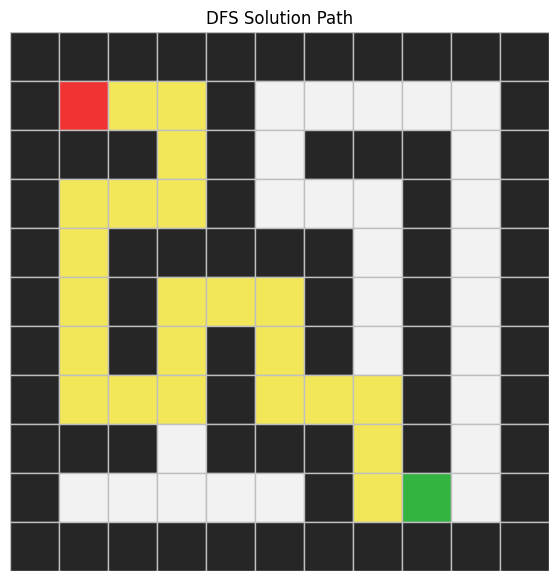

In [20]:
path = custom_results_2[0].path
dfs_result = results[0]
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=path,
    title="DFS Solution Path",
)

Interpretation 
This map was designed so that DFS would explore dead ends before finding the goal. Both BFS and DFS successfully found a solution with the same depth and cost of 23. BFS expanded 31 nodes, while DFS expanded 29 nodes, indicating that DFS was able to find the correct path relatively quickly despite the presence of dead ends. As a result, the intended disadvantage of DFS is not strongly reflected in the results. DLS returned a cutoff because the depth limit of 20 was smaller than the solution depth of 23, preventing it from reaching the goal. IDS successfully found the optimal solution with a depth and cost of 23, but expanded 322 nodes because it repeatedly performed depth-limited searches. Overall, BFS, DFS, and IDS all found the solution, while DLS was limited by its depth bound. 

Reflection Questions

15.1 Problem Formulation
1. What is the state of this lab? 
- state is the position of the drone on the grid that represents where the drone is at any point during the navigation. 
2. What is an action? 
- An action is the move that the drone makes from its current position to the goal state. The moves are up, down, left and right within the grid boundary and there is no obstacle. 
3. What does the result function do? 
- It returns the next position of the drone after applying the action. 
4. Why is it useful to separate the problem definition from the search algorithm?
- By separating the problem from the algorithm, the same search algorithm can be used again for any problem without recreating or modification. 

15.2 BFS
1. Why does BFS use a FIFO queue? 
- Because it needs to explore all the nodes at the current level before moving to the next depth. 
2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid? 
- BFS explores level by level, so when it reaches the goal, it only takes a few steps. And on the unweighted grid every move costs the same amount, so a few steps means the shortest path. 
3. What role does the reached set play in BFS? 
- The reached set saves the visited states, preventing the agent from revisiting the state and creating a cycle and waste of time. 


15.3 DFS
1. Why does DFS use a stack? 
- Because it explores in depth, it goes deep into the path before exploring the rest of the states. It will follow a LIFO order where the recently added node gets explored first. 
2. Is DFS guaranteed to find the shortest path? Explain. 
- No, because DFS explores one direction deeply before trying others, and it might find a long path to get to the goal although a short path might exist. 
3. Under what conditions can DFS use less memory than BFS? 
- In a case where the goal state is deep in the search. This time BFS explores branches and stores them as reached in memory, this takes so much memory. However, theDFS only follows the deep path and reaches the goal state with less memory. 
4. Under what conditions can DFS perform badly? 
- When the goal is near the top of the tree, but the tree has very long branches. This time, the DFS will go in depth exploring deep down a dead-path before coming back to top and finding the goal. 


15.4 DLS
1. What happens when the depth limit is too small? 
- When the depth limit is smaller than the depth of the goal, DLS will never find the solution. This results in a cutoff result indicating that the search was stopped because of a limit not because the goal is unreachable. 
2. What is the meaning of "cutoff"? 
- Cutoff means the algorithm search has stopped searching because it reaches the depth limit before finding the solution. 
3. How is DLS different from ordinary DFS? 
- DLS is a type of DFS which explores states until it reaches the depth limit. Once it reaches the limit it stops exploring unlike DFS which keeps going. 
4. Why do we use path-cycle checking in DLS? 
- Path-cycle in DLS gives the same function as reached in BFS. Path-cycle prevents the agent from revisiting states that are already visited. 

15.5 IDS
1. Why does IDS repeat DLS with increasing limits? 
- The limit of the gold is not known at the beginning, so IDS starting from 0 and increasing the limit reaches the goal. Compared to IDL, IDS gives a large limit to reach the goal. 
2. Why can IDS be complete even though DLS with a small limit is not? 
- Let’s say the goal is at depth 57, and DLS  has limit 30 and DIS limit 60. DLS will kiss the goal because it can’t reach the goal limit. However, IDS will find the goal because it has a large depth limit.
3. Why does IDS use less memory than BFS? 
- Because IDS has DLS, it only stores the current path. Whereas, BFS stores all nodes explored, this takes up much storage. So, IDS takes less memory. 
4. What is the cost of repeatedly searching from the root? 
- It creates insignificant work. Because the nodes grow with depth, most of the searching work happens at the deepest level, so re-explanding the roots is insignificant. 


15.6 Real-World Drone Context
1. In a real drone application, what might make one route safer or more practical than another? 
- In real drone applications, there are different factors to consider such as battery consumption, height restriction, wind resistance, terrain stability and so on. The shortest path might not be the safest if it contains restricted areas, so it’s a good practice to balance those factors. 
2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
- BFS because all moves are equally costly and the goal is in a few steps. BFS explores level by level returning the solution the first time the agent reached the goal. 
3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain. 
- DLS would be used. Because it sets a depth limit and controls how far the drone can go searching. And if the drone has limited battery and should stay within the limit, DLS is best. 
4. What limitations does this grid model have compared with real drone navigation? 
- The grid model makes the assumption that the environment is static, the cost is uniform and the movements are only four. However, the real drone navigates a variable environment, dynamic obstacles such as birds, and diagonal movements which require real-time decision making. 
